In [1]:
import sys, os
import numpy as np

import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)
import fci

np.set_printoptions(precision=6, suppress=True, linewidth=120)

In [2]:
basis = fci.SlaterBasis(8, 4)          # 8 spin-orbitals, 4 particles
print("dimension:", basis.dim, "= C(8,4)")
for s in basis.states[:5]:
    print(format(s, "08b"), "  occupied:", [k for k in range(8) if s >> k & 1])

dimension: 70 = C(8,4)
00001111   occupied: [0, 1, 2, 3]
00010111   occupied: [0, 1, 2, 4]
00011011   occupied: [0, 1, 3, 4]
00011101   occupied: [0, 2, 3, 4]
00011110   occupied: [1, 2, 3, 4]


In [3]:
state = 0b00101101
for p in (1, 4):
    sign, new = fci.create(state, p)
    if sign:
        print(f"a+_{p} |{state:08b}> = {sign:+d} |{new:08b}>")
    else:
        print(f"a+_{p} |{state:08b}> = 0   (orbital already occupied)")

a+_1 |00101101> = -1 |00101111>
a+_4 |00101101> = -1 |00111101>


In [4]:
reference = basis.states[0]
levels = basis.excitation_levels(reference)
for k in range(5):
    print(f"{k}p-{k}h: {(levels == k).sum():3d}")
print("total  :", basis.dim)

0p-0h:   1
1p-1h:  16
2p-2h:  36
3p-3h:  16
4p-4h:   1
total  : 70


In [5]:
fci.demo_full_space()

1. The pairing model in the full CI space
four levels, four particles: 8 spin-orbitals,
dimension of the full space  = 70 = C(8,4)
seniority-zero subspace      = 6 (chapter 4 worked here)

determinants by excitation level relative to the reference:
   0p-0h:    1
   1p-1h:   16
   2p-2h:   36
   3p-3h:   16
   4p-4h:    1


In [6]:
model = fci.PairingFCI(levels=4, n_particles=4, g=1.0, xi=1.0)
w, v = np.linalg.eigh(model.matrix())
print("ground-state energy, full 70-dimensional space :", f"{w[0]:.8f}")
print("Table 4.2, seniority-zero subspace, g = 1      :  0.63554847")

psi = v[:, 0]
odd = np.where(model.levels_of % 2 == 1)[0]
print("\nlargest amplitude on a broken-pair determinant :",
      f"{np.abs(psi[odd]).max():.2e}")

ground-state energy, full 70-dimensional space : 0.63554847
Table 4.2, seniority-zero subspace, g = 1      :  0.63554847

largest amplitude on a broken-pair determinant : 5.55e-17


In [7]:
fci.demo_block_structure()

2. The block structure of the Hamiltonian matrix
        0p-0h  1p-1h  2p-2h  3p-3h  4p-4h  
 0p-0h    x      0      x      0      0    
 1p-1h    0      x      0      x      0    
 2p-2h    x      0      x      0      x    
 3p-3h    0      x      0      x      0    
 4p-4h    0      0      x      0      x    

A two-body operator connects determinants differing by at most
two single-particle states, so the matrix is banded in the
excitation level: the Condon-Slater rules of chapter 2 read as a
statement about sparsity.


In [8]:
fci.demo_truncations()

3. Truncating the CI expansion
     g       E_ref           CIS           CID          CISD           FCI
  0.25    1.750000    1.75000000    1.73050700    1.73050700    1.73045985
  0.50    1.500000    1.50000000    1.41759645    1.41759645    1.41677428
  1.00    1.000000    1.00000000    0.64890655    0.64890655    0.63554847
  2.00    0.000000    0.00000000   -1.35208670   -1.35208670   -1.48965216

basis sizes: 0p-0h and below:   1   1p-1h and below:  17   2p-2h and below:  53   3p-3h and below:  69   4p-4h and below:  70   full: 70

Singles alone change nothing: the pairing interaction cannot
break a pair, so <Phi_0|H|Phi_i^a> = 0 and CIS = reference.
Doubles capture almost all of the correlation energy, and CISD
equals CID here for the same reason.


In [9]:
fci.demo_size_consistency()

4. Size consistency
One subsystem: two levels, two particles.  Then two identical
copies with no interaction between them.  A size-consistent
method must give exactly twice the energy.

     g          E(A)        2 E(A)         E(AB)        error   method
  0.25   -0.13278222   -0.26556444   -0.26556444     0.00e+00   FCI
  0.25   -0.13278222   -0.26556444   -0.26550480     5.96e-05   CID
  0.50   -0.28077641   -0.56155281   -0.56155281     0.00e+00   FCI
  0.50   -0.28077641   -0.56155281   -0.56066017     8.93e-04   CID
  1.00   -0.61803399   -1.23606798   -1.23606798    -2.22e-16   FCI
  1.00   -0.61803399   -1.23606798   -1.22474487     1.13e-02   CID

Full CI passes to machine precision.  CID does not: for the
combined system, both subsystems being doubly excited at once is
a quadruple excitation, and CID has no room for it.  The error
grows with the number of subsystems, so truncated CI becomes
useless for large systems.  This is the failure that
coupled-cluster theory repairs b

In [10]:
fci.demo_hubbard()

5. The Hubbard ring in the momentum basis
   U/t        E_ref           CIS           CID          CISD           FCI  % recovered


   1.0    -6.500000   -6.50000000   -6.59980159   -6.59989778   -6.60115829       98.66%


   2.0    -5.000000   -5.00000000   -5.38877703   -5.39026458   -5.40945685       94.95%


   4.0    -2.000000   -2.00000000   -3.41192866   -3.43018837   -3.66870618       84.61%


   8.0     4.000000    2.48338852   -0.36779217   -1.05692183   -2.04813089       72.22%

six sites at half filling: dimension 400 = C(6,3)^2
determinants by excitation level: 0p-0h: 1  1p-1h: 18  2p-2h: 99  3p-3h: 164  4p-4h: 99  5p-5h: 18  6p-6h: 1

As U grows the reference determinant becomes a worse starting
point and the doubles recover a smaller fraction of the
correlation energy -- the signature of strong correlation.


In [11]:
for U in (1.0, 2.0, 4.0, 8.0):
    h = fci.HubbardFCI(sites=6, n_up=3, n_down=3, t=1.0, U=U)
    M = h.matrix()
    r = h.index[h.reference]
    singles = np.where(h.levels_of == 1)[0]
    coupling = np.abs(M[r, singles]).max()
    lowest = np.linalg.eigvalsh(M[np.ix_(singles, singles)])[0]
    print(f"U/t = {U:4.1f}   max |<Phi_0|H|Phi_i^a>| = {coupling:8.2e}"
          f"   E_ref = {M[r, r]:9.6f}"
          f"   lowest singles eigenvalue = {lowest:9.6f}")

U/t =  1.0   max |<Phi_0|H|Phi_i^a>| = 0.00e+00   E_ref = -6.500000   lowest singles eigenvalue = -4.858678


U/t =  2.0   max |<Phi_0|H|Phi_i^a>| = 0.00e+00   E_ref = -5.000000   lowest singles eigenvalue = -3.758306


U/t =  4.0   max |<Phi_0|H|Phi_i^a>| = 0.00e+00   E_ref = -2.000000   lowest singles eigenvalue = -1.632993
U/t =  8.0   max |<Phi_0|H|Phi_i^a>| = 0.00e+00   E_ref =  4.000000   lowest singles eigenvalue =  2.483389


In [12]:
fci.demo_exponential_wall()

6. The exponential wall
                          system   n_sp    N        dimension
                       toy model     10    5        2.520e+02
               small shell model     20   10        1.848e+05
    oxygen-16 neutrons, 4 shells     40    8        7.690e+07
         half filling, 40 states     40   20        1.378e+11
         half filling, 80 states     80   40        1.075e+23

At half filling the binomial coefficient becomes exponential:
     n        C(n, n/2)    2^n / sqrt(n)
    10        2.520e+02        3.238e+02
    20        1.848e+05        2.345e+05
    40        1.378e+11        1.738e+11
    80        1.075e+23        1.352e+23
   160        9.205e+46        1.155e+47

Oxygen-16 in the four lowest major shells (0s, 0p, 1s0d, 1p0f)
has 40 single-particle states for each species, so the eight
neutrons give C(40,8) = 7.690e+07 determinants and the full
proton-neutron space 5.914e+15.  Symmetries reduce this,
but adding one more shell or relaxing the truncation 

In [13]:
model = fci.PairingFCI(levels=4, n_particles=4, g=1.0, xi=1.0)
w, v = np.linalg.eigh(model.matrix())
psi = v[:, 0]

occ = np.array([[(s >> k) & 1 for k in range(8)] for s in model.basis.states])
labels_A = [tuple(row[:4]) for row in occ]     # levels 1 and 2
labels_B = [tuple(row[4:]) for row in occ]     # levels 3 and 4
iA = {l: i for i, l in enumerate(sorted(set(labels_A)))}
iB = {l: i for i, l in enumerate(sorted(set(labels_B)))}

M = np.zeros((len(iA), len(iB)))
for c, (a, b) in enumerate(zip(labels_A, labels_B)):
    M[iA[a], iB[b]] = psi[c]

s = np.linalg.svd(M, compute_uv=False)
s = s[s > 1e-12]
print("Schmidt coefficients:", np.round(s, 6))
p = s**2
print("entanglement entropy:", f"{-np.sum(p * np.log2(p)):.6f}", "bits")
print("\nOnly a handful of Schmidt states carry any weight -- which is exactly")
print("what makes a compressed representation possible.")

Schmidt coefficients: [0.931471 0.361414 0.040586 0.00977 ]
entanglement entropy: 0.577799 bits

Only a handful of Schmidt states carry any weight -- which is exactly
what makes a compressed representation possible.


In [14]:
print(open(fci.__file__).read())

"""
Full configuration interaction, and what happens when it is truncated.

Companion code to chapter 5 of *Quantum mechanics for Many-particle Systems*.

The Hamiltonian is built in the basis of all Slater determinants that can be
formed from a truncated set of single-particle states, and diagonalised.  Every
determinant is classified by its excitation level relative to a reference, so
that the block structure of the matrix can be displayed and the truncated
schemes -- CIS, CID, CISD and so on -- obtained by restricting the basis.

    SlaterBasis      -- determinants as bit strings, with fermionic phases
    PairingFCI       -- the pairing model in the full space, not just the
                        seniority-zero subspace
    HubbardFCI       -- the Hubbard ring in the momentum basis, where the
                        free-fermion determinant is the natural reference
    hilbert_growth   -- how the dimension explodes

Author: Morten Hjorth-Jensen
"""

from itertools import combinat

In [15]:
import matplotlib.pyplot as plt

SlaterBasis(14, 7).dim = 3432  fci.comb(14, 7) = 3432


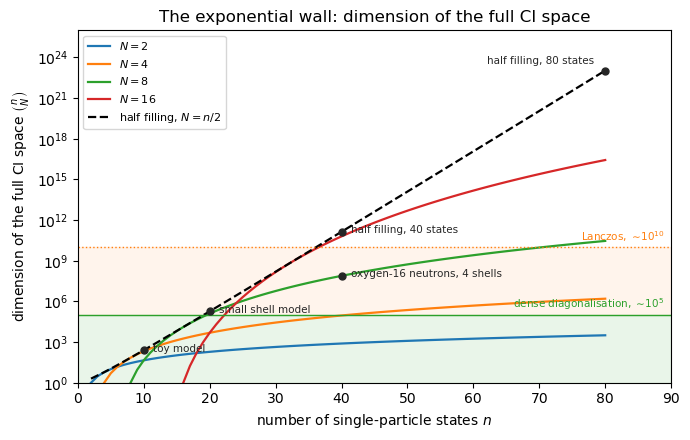

In [16]:
# the module's own binomial, checked against an enumerated basis
check = fci.SlaterBasis(14, 7)
print("SlaterBasis(14, 7).dim =", check.dim,
      " fci.comb(14, 7) =", fci.comb(14, 7))

n_grid = np.arange(2, 81)

fig, ax = plt.subplots(figsize=(7, 4.5))

for N in (2, 4, 8, 16):
    ns = n_grid[n_grid >= N]
    ax.plot(ns, [fci.comb(int(n), N) for n in ns], lw=1.6, label=f"$N = {N}$")

half = n_grid[n_grid % 2 == 0]
ax.plot(half, [fci.comb(int(n), int(n) // 2) for n in half], "k--", lw=1.6,
        label=r"half filling, $N = n/2$")

# the landmarks of fci.hilbert_growth(), the table of demo_exponential_wall
for label, n_sp, N, dim in fci.hilbert_growth():
    ax.plot(n_sp, dim, "o", color="0.15", ms=5, zorder=5)
    offset, align = ((-8, 5), "right") if n_sp >= 60 else ((7, -1), "left")
    ax.annotate(label, (n_sp, dim), textcoords="offset points",
                xytext=offset, ha=align, fontsize=7.5, color="0.15")

ax.axhspan(1, 1e5, color="C2", alpha=0.10)
ax.axhspan(1e5, 1e10, color="C1", alpha=0.08)
ax.axhline(1e5, color="C2", lw=1.0)
ax.axhline(1e10, color="C1", lw=1.0, ls=":")
ax.text(89, 3.0e5, r"dense diagonalisation, $\sim\!10^{5}$",
        fontsize=7.5, color="C2", ha="right")
ax.text(89, 3.0e10, r"Lanczos, $\sim\!10^{10}$",
        fontsize=7.5, color="C1", ha="right")

ax.set_yscale("log")
ax.set_xlim(0, 90)
ax.set_ylim(1, 1e26)
ax.set_xlabel("number of single-particle states $n$")
ax.set_ylabel(r"dimension of the full CI space $\binom{n}{N}$")
ax.set_title("The exponential wall: dimension of the full CI space")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

basis sizes at g = 1:
   CIS        37
   CISD      262
   CISDTQ    887
   FCI       924


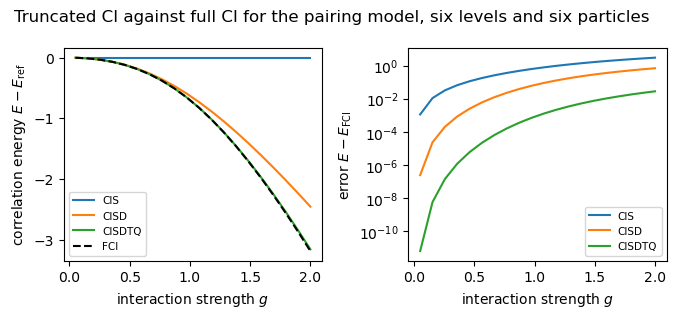

In [17]:
g_grid = np.linspace(0.05, 2.0, 20)
truncations = [(1, "CIS"), (2, "CISD"), (4, "CISDTQ")]

energy = {label: [] for _, label in truncations}
e_ref, e_fci = [], []

for g in g_grid:
    model = fci.PairingFCI(levels=6, n_particles=6, g=g, xi=1.0)
    e_ref.append(model.reference_energy())
    e_fci.append(model.energies(None)[0])
    for level, label in truncations:
        energy[label].append(model.energies(level)[0])

e_ref = np.array(e_ref)
e_fci = np.array(e_fci)
energy = {k: np.array(v) for k, v in energy.items()}

print("basis sizes at g = 1:")
m1 = fci.PairingFCI(levels=6, n_particles=6, g=1.0)
for level, label in truncations:
    print(f"   {label:8s} {m1.energies(level)[1]:4d}")
print(f"   {'FCI':8s} {m1.basis.dim:4d}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2))

for _, label in truncations:
    ax1.plot(g_grid, energy[label] - e_ref, lw=1.5, label=label)
ax1.plot(g_grid, e_fci - e_ref, "k--", lw=1.5, label="FCI")
ax1.set_xlabel("interaction strength $g$")
ax1.set_ylabel(r"correlation energy $E - E_{\mathrm{ref}}$")
ax1.legend(fontsize=7.5, loc="lower left")

for _, label in truncations:
    ax2.semilogy(g_grid, np.maximum(energy[label] - e_fci, 1e-16),
                 lw=1.5, label=label)
ax2.set_xlabel("interaction strength $g$")
ax2.set_ylabel(r"error $E - E_{\mathrm{FCI}}$")
ax2.legend(fontsize=7.5, loc="lower right")

fig.suptitle("Truncated CI against full CI for the pairing model, "
             "six levels and six particles")
fig.tight_layout()
plt.show()

CID      error at g = 1: n=1: +0.00e+00  n=2: +1.13e-02  n=3: +3.12e-02
CISDTQ   error at g = 1: n=1: +0.00e+00  n=2: -2.22e-16  n=3: +9.08e-04
FCI      error at g = 1: n=1: +0.00e+00  n=2: -2.22e-16  n=3: -3.11e-15


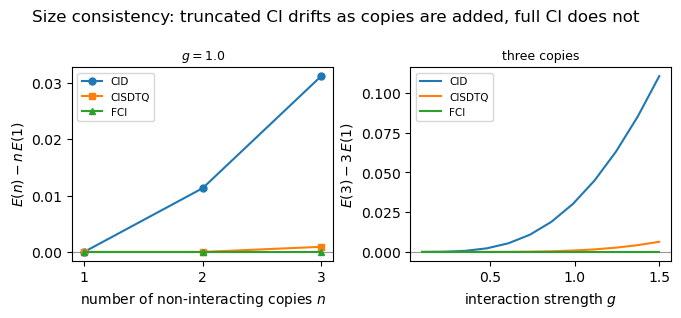

In [18]:
schemes = [(2, "CID"), (4, "CISDTQ"), (None, "FCI")]
copies = [1, 2, 3]

# (a) against the number of copies, at fixed coupling
g_fixed = 1.0
one = fci.NonInteractingCopies(g=g_fixed, subsystems=1)
error_vs_n = {}
for level, label in schemes:
    e_one = one.energies(level)[0]
    error_vs_n[label] = [
        fci.NonInteractingCopies(g=g_fixed, subsystems=n).energies(level)[0]
        - n * e_one for n in copies]

# (b) three copies, against the coupling
g_grid3 = np.linspace(0.1, 1.5, 12)
error_vs_g = {label: [] for _, label in schemes}
for g in g_grid3:
    one = fci.NonInteractingCopies(g=g, subsystems=1)
    three = fci.NonInteractingCopies(g=g, subsystems=3)
    for level, label in schemes:
        error_vs_g[label].append(three.energies(level)[0]
                                 - 3 * one.energies(level)[0])

for label in ("CID", "CISDTQ", "FCI"):
    print(f"{label:8s} error at g = 1: "
          + "  ".join(f"n={n}: {e:+.2e}"
                      for n, e in zip(copies, error_vs_n[label])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2))
marker = {"CID": "o", "CISDTQ": "s", "FCI": "^"}

for _, label in schemes:
    ax1.plot(copies, error_vs_n[label], marker[label] + "-",
             lw=1.5, ms=5, label=label)
ax1.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax1.set_xticks(copies)
ax1.set_xlabel("number of non-interacting copies $n$")
ax1.set_ylabel(r"$E(n) - n\,E(1)$")
ax1.set_title(f"$g = {g_fixed}$", fontsize=9)
ax1.legend(fontsize=7.5, loc="upper left")

for _, label in schemes:
    ax2.plot(g_grid3, error_vs_g[label], lw=1.5, label=label)
ax2.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax2.set_xlabel("interaction strength $g$")
ax2.set_ylabel(r"$E(3) - 3\,E(1)$")
ax2.set_title("three copies", fontsize=9)
ax2.legend(fontsize=7.5, loc="upper left")

fig.suptitle("Size consistency: truncated CI drifts as copies are added, "
             "full CI does not")
fig.tight_layout()
plt.show()